**<h3><center>Desafio Titanic do Kaggle<center><h3>**

Esse jupyter notebook tem como objetivo criar um modelo que possa predizer os sobreviventes do Titanic. É um desafio do site [Kaggle.com](https://www.kaggle.com/competitions/titanic/overview), os datasets e a descrição do desafio estão disponíveis no link mencionado.

<h3>Analise exploratória dos dados<h3>

Primeiramente vamos conhecer nossos dados:

In [14]:
from pathlib import Path
import pandas as pd

# Obtendo dados
train_data = pd.read_csv(Path("datasets/train.csv"))
test_data = pd.read_csv(Path("datasets/test.csv"))

# Primeiras cinco linhas do dataset
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Removendo colunas não importantes: PassengerId, Name, Ticket e Cabin:

In [15]:
train_data = train_data.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

Informação sobre as colunas do dataframe:

In [16]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB


Visão geral dos dados:

In [17]:
train_data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Histograma dos atributos:

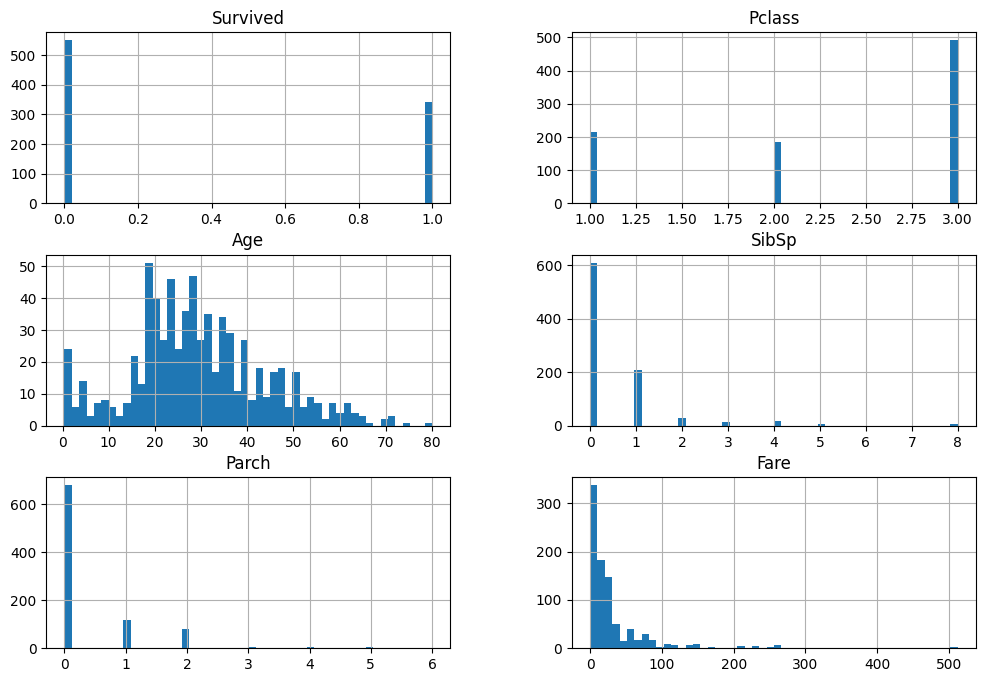

In [18]:
import matplotlib.pyplot as plt

train_data.hist(bins=50, figsize=(12,8))
plt.show()

Criando conjunto de teste:

In [19]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(train_data, test_size=0.2, random_state=42)

**Buscando correlações:**

Coeficente de correlação padrão

In [20]:
corr_matrix = train_set.corr(numeric_only=True)
corr_matrix["Survived"].sort_values(ascending=False)

Survived    1.000000
Fare        0.246641
Parch       0.078311
SibSp      -0.047602
Age        -0.059695
Pclass     -0.321750
Name: Survived, dtype: float64

Gráfico usando só os atributos interessantes:

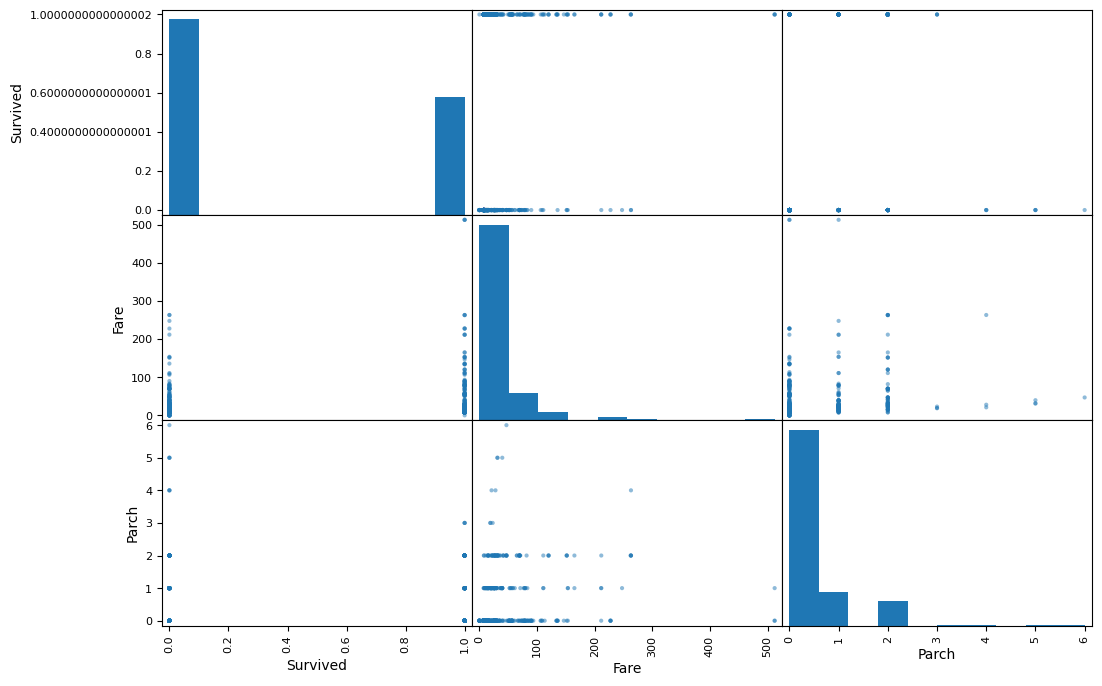

In [23]:
from pandas.plotting import scatter_matrix

attributes = ["Survived", "Fare", "Parch"]
scatter_matrix(train_set[attributes], figsize=(12,8))
plt.show()

<h3>Preparando os dados para os algoritmos ML<h3>